# TFLite Conversion & Edge Benchmark

Converts all 3 trained `.h5` models to `.tflite` and benchmarks:
- Model size (target: < 100 KB each)
- Inference latency (target: < 50 ms per clip)
- Accuracy delta between Keras and TFLite (quantisation should not meaningfully hurt accuracy)

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
os.chdir(os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == 'notebooks' else None

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from src.edge_inference import convert_to_tflite, benchmark_model, TFLiteClassifier
from src.train_braking import load_splits as load_braking_splits
from src.train_startup import load_splits as load_startup_splits
from src.train_idle import load_splits as load_idle_splits

MODELS_DIR = Path('models')
print(f'TensorFlow {tf.__version__}')

TensorFlow 2.19.0


## 1 — Load All Splits

In [2]:
datasets = {
    'braking': load_braking_splits(),
    'startup': load_startup_splits(),
    'idle':    load_idle_splits(),
}

for name, (X_tr, X_v, X_te, y_tr, y_v, y_te, labels) in datasets.items():
    print(f'{name:<10} train={X_tr.shape}  test={X_te.shape}  classes={labels}')

braking    train=(321, 40, 78, 1)  test=(23, 40, 78, 1)  classes=[np.str_('normal_brakes'), np.str_('worn_out_brakes')]
startup    train=(378, 40, 78, 1)  test=(27, 40, 78, 1)  classes=[np.str_('normal_engine_startup'), np.str_('bad_ignition'), np.str_('dead_battery')]
idle       train=(1290, 40, 78, 1)  test=(93, 40, 78, 1)  classes=[np.str_('normal_engine_idle'), np.str_('low_oil'), np.str_('power_steering'), np.str_('serpentine_belt')]


## 2 — Convert to TFLite (int8 quantised)

In [3]:
model_files = {
    'braking': 'braking_model',
    'startup': 'startup_model',
    'idle':    'idle_model',
}

for name, stem in model_files.items():
    h5_path     = MODELS_DIR / f'{stem}.h5'
    tflite_path = MODELS_DIR / f'{stem}.tflite'
    X_tr = datasets[name][0]   # representative dataset = training MFCCs

    convert_to_tflite(
        h5_path, tflite_path,
        representative_data=X_tr,
        quantize=True,
    )

INFO:tensorflow:Assets written to: C:\Users\HP8CG\AppData\Local\Temp\tmpz1ie8kyp\assets


INFO:tensorflow:Assets written to: C:\Users\HP8CG\AppData\Local\Temp\tmpz1ie8kyp\assets


Saved artifact at 'C:\Users\HP8CG\AppData\Local\Temp\tmpz1ie8kyp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 78, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1740182199888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740182201232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740182201424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740182202000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740182200080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740182202192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740182200464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740182202960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740182203536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740182199504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  174018

c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Converted braking_model.h5 -> braking_model.tflite  (24.8 KB)
INFO:tensorflow:Assets written to: C:\Users\HP8CG\AppData\Local\Temp\tmpgktzruax\assets


...

Converted startup_model.h5 -> startup_model.tflite  (24.8 KB)
INFO:tensorflow:Assets written to: C:\Users\HP8CG\AppData\Local\Temp\tmpbs_drbpz\assets


INFO:tensorflow:Assets written to: C:\Users\HP8CG\AppData\Local\Temp\tmpbs_drbpz\assets


Saved artifact at 'C:\Users\HP8CG\AppData\Local\Temp\tmpbs_drbpz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 78, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1740221572560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740221571408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740225989712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740225988752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740225991056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740225990672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740225992592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740225993168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740225993360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740225992208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  174022

c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Converted idle_model.h5 -> idle_model.tflite  (38.7 KB)


## 3 — Benchmark All 3 Models

In [4]:
results = []
for name, stem in model_files.items():
    h5_path     = MODELS_DIR / f'{stem}.h5'
    tflite_path = MODELS_DIR / f'{stem}.tflite'
    X_tr, X_v, X_te, y_tr, y_v, y_te, labels = datasets[name]

    res = benchmark_model(h5_path, tflite_path, X_te, y_te, labels)
    res['state'] = name
    results.append(res)
    print(f"{name}: {res['tflite_size_kb']} KB | "
          f"acc {res['h5_accuracy']:.3f} -> {res['tflite_accuracy']:.3f} | "
          f"{res['mean_latency_ms']:.2f} ms")

df = pd.DataFrame(results).set_index('state')
df = df[['h5_size_kb', 'tflite_size_kb', 'size_reduction_pct',
         'h5_accuracy', 'tflite_accuracy', 'accuracy_delta',
         'mean_latency_ms', 'under_100kb', 'under_50ms']]
df

c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


braking: 24.8 KB | acc 0.957 -> 0.957 | 0.68 ms


startup: 24.8 KB | acc 0.889 -> 0.889 | 0.35 ms
idle: 38.7 KB | acc 0.763 -> 0.774 | 0.30 ms


,h5_size_kb,tflite_size_kb,size_reduction_pct,h5_accuracy,tflite_accuracy,accuracy_delta,mean_latency_ms,under_100kb,under_50ms
state,,,,,,,,,
braking,250.5,24.8,90.1,0.9565,0.9565,0.0000,0.68,True,True
startup,250.5,24.8,90.1,0.8889,0.8889,0.0000,0.35,True,True
idle,396.9,38.7,90.2,0.7634,0.7742,0.0108,0.30,True,True


## 4 — Visualise Benchmark Results

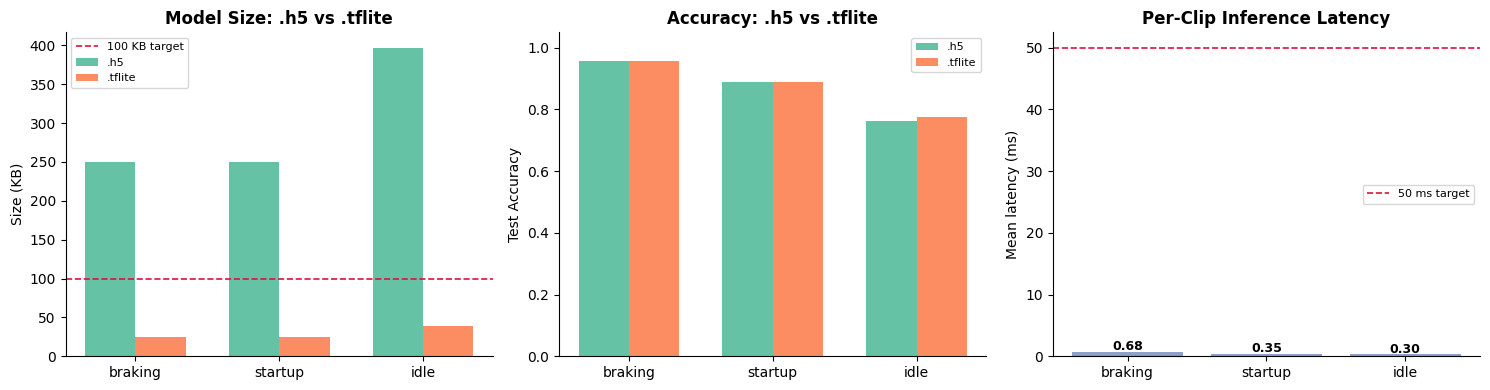

Saved -> results/tflite_benchmark.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
states = df.index.tolist()
colors = plt.cm.Set2.colors

# Size comparison
x = np.arange(len(states))
w = 0.35
axes[0].bar(x - w/2, df['h5_size_kb'], w, label='.h5', color=colors[0])
axes[0].bar(x + w/2, df['tflite_size_kb'], w, label='.tflite', color=colors[1])
axes[0].axhline(100, color='crimson', linestyle='--', linewidth=1.2, label='100 KB target')
axes[0].set_xticks(x)
axes[0].set_xticklabels(states)
axes[0].set_ylabel('Size (KB)')
axes[0].set_title('Model Size: .h5 vs .tflite', fontweight='bold')
axes[0].legend(fontsize=8)

# Accuracy comparison
axes[1].bar(x - w/2, df['h5_accuracy'], w, label='.h5', color=colors[0])
axes[1].bar(x + w/2, df['tflite_accuracy'], w, label='.tflite', color=colors[1])
axes[1].set_xticks(x)
axes[1].set_xticklabels(states)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Accuracy: .h5 vs .tflite', fontweight='bold')
axes[1].legend(fontsize=8)

# Latency
bars = axes[2].bar(states, df['mean_latency_ms'], color=colors[2])
axes[2].axhline(50, color='crimson', linestyle='--', linewidth=1.2, label='50 ms target')
for bar, v in zip(bars, df['mean_latency_ms']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_ylabel('Mean latency (ms)')
axes[2].set_title('Per-Clip Inference Latency', fontweight='bold')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/tflite_benchmark.png', bbox_inches='tight')
plt.show()
print('Saved -> results/tflite_benchmark.png')

## 5 — Spot-Check Single-Clip Inference

In [6]:
for name, stem in model_files.items():
    tflite_path = MODELS_DIR / f'{stem}.tflite'
    X_tr, X_v, X_te, y_tr, y_v, y_te, labels = datasets[name]

    clf = TFLiteClassifier(tflite_path, labels)
    sample = X_te[0, ..., 0]   # drop channel dim, predict() re-adds it
    result = clf.predict(sample)

    print(f'{name}:')
    print(f"  predicted : {result['fault_label']}  (true: {labels[y_te[0]]})")
    print(f"  confidence: {result['confidence']:.3f}")
    print(f"  latency   : {result['latency_ms']:.2f} ms")
    print(f"  all probs : {result['all_probabilities']}")
    print()

braking:
  predicted : normal_brakes  (true: normal_brakes)
  confidence: 0.875
  latency   : 0.48 ms
  all probs : {np.str_('normal_brakes'): 0.875, np.str_('worn_out_brakes'): 0.125}

startup:
  predicted : normal_engine_startup  (true: normal_engine_startup)
  confidence: 0.973
  latency   : 0.54 ms
  all probs : {np.str_('normal_engine_startup'): 0.97265625, np.str_('bad_ignition'): 0.0078125, np.str_('dead_battery'): 0.01953125}

idle:
  predicted : normal_engine_idle  (true: normal_engine_idle)
  confidence: 0.992
  latency   : 0.71 ms
  all probs : {np.str_('normal_engine_idle'): 0.9921875, np.str_('low_oil'): 0.0078125, np.str_('power_steering'): 0.0, np.str_('serpentine_belt'): 0.0}



c:\Users\HP8CG\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 6 — Save Benchmark Report

In [7]:
report_lines = ['# Revio — Edge Deployment Benchmark\n']
report_lines.append('Generated from notebooks/04_tflite_conversion_benchmark.ipynb\n')
report_lines.append('| State | .h5 (KB) | .tflite (KB) | Size reduction | Keras acc | TFLite acc | Latency (ms) | <100KB | <50ms |')
report_lines.append('|---|---|---|---|---|---|---|---|---|')
for state, row in df.iterrows():
    report_lines.append(
        f"| {state} | {row['h5_size_kb']} | {row['tflite_size_kb']} | "
        f"{row['size_reduction_pct']}% | {row['h5_accuracy']:.4f} | "
        f"{row['tflite_accuracy']:.4f} | {row['mean_latency_ms']:.2f} | "
        f"{'Yes' if row['under_100kb'] else 'No'} | "
        f"{'Yes' if row['under_50ms'] else 'No'} |"
    )

report_text = '\n'.join(report_lines)
Path('results/benchmark.md').write_text(report_text, encoding='utf-8')
print(report_text)
print('\nSaved -> results/benchmark.md')

# Revio — Edge Deployment Benchmark

Generated from notebooks/04_tflite_conversion_benchmark.ipynb

| State | .h5 (KB) | .tflite (KB) | Size reduction | Keras acc | TFLite acc | Latency (ms) | <100KB | <50ms |
|---|---|---|---|---|---|---|---|---|
| braking | 250.5 | 24.8 | 90.1% | 0.9565 | 0.9565 | 0.68 | Yes | Yes |
| startup | 250.5 | 24.8 | 90.1% | 0.8889 | 0.8889 | 0.35 | Yes | Yes |
| idle | 396.9 | 38.7 | 90.2% | 0.7634 | 0.7742 | 0.30 | Yes | Yes |

Saved -> results/benchmark.md


## Summary

All 3 models converted to `.tflite` for edge deployment. Results in `results/benchmark.md`.

**Next steps:**
- `src/risk_scorer.py` — rule-based risk tier from confidence score
- `src/narrative.py` — template-based driver alert text
- `src/tts_alert.py` — offline TTS (pyttsx3)
- `demo/app.py` — Streamlit demo UI